## Линейный график (Line chart)

In [25]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt 

## 1 Установливаем соединение с базой данных.

In [26]:
conn = sqlite3.connect('/Users/cleganeb/Desktop/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/data/checking-logs.sqlite')

## 2 Выполним запрос, который извлекает дату и время из pageviews таблицы, выбирем только пользователей, но не администраторов.

In [27]:
query = """
SELECT uid, datetime
FROM pageviews
WHERE uid LIKE 'user_%'
ORDER BY uid ASC
"""
pageviews = pd.io.sql.read_sql(query, conn)
display(pageviews.head())

,uid,datetime
0,user_1,2020-04-26 21:53:59.624136
1,user_1,2020-04-26 22:06:19.478143
2,user_1,2020-04-26 22:12:09.614497
3,user_1,2020-04-30 19:29:01.831635
4,user_1,2020-05-05 20:26:32.894852


## 3 С помощью библиотеки Pandas создадим новый датафрейм, в котором подсчитываются посещения, сгруппированные по дате.

In [28]:
pageviews['date'] = pd.to_datetime(pageviews['datetime']).dt.date
grouped_pageviews = pageviews.groupby('date').size().reset_index(name='visits_count')
display(grouped_pageviews.head())
print(len(grouped_pageviews))

,date,visits_count
0,2020-04-17,1
1,2020-04-18,23
2,2020-04-19,15
3,2020-04-21,3
4,2020-04-22,1


33


## 4 Используя метод Pandas .plot(), создадим график:
## -Размер шрифта пусть будет 8.
## -Размер фигуры пусть будет (15, 8).
## -График будет иметь заголовок «Просмотры в день».

(array([18369., 18373., 18377., 18381., 18383., 18387., 18391., 18395.,
        18399., 18403.]),
 [Text(18369.0, 0, '2020-04-17'),
  Text(18373.0, 0, '2020-04-21'),
  Text(18377.0, 0, '2020-04-25'),
  Text(18381.0, 0, '2020-04-29'),
  Text(18383.0, 0, '2020-05-01'),
  Text(18387.0, 0, '2020-05-05'),
  Text(18391.0, 0, '2020-05-09'),
  Text(18395.0, 0, '2020-05-13'),
  Text(18399.0, 0, '2020-05-17'),
  Text(18403.0, 0, '2020-05-21')])

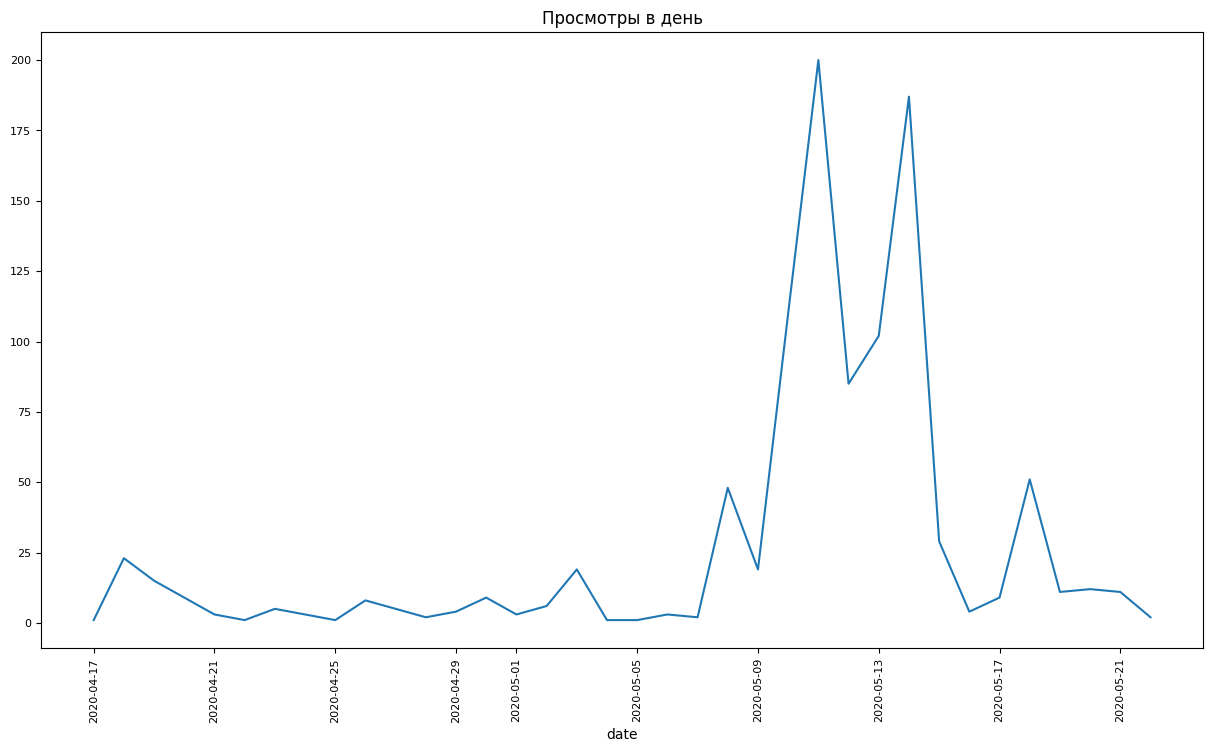

In [29]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.tick_params(axis='both', labelsize=8)
grouped_pageviews.set_index('date').plot(ax=ax, kind='line', legend=False)
ax.set_title("Просмотры в день", fontsize=12)
plt.xticks(rotation=90)

## 5 Закроем соединение с базой данных.

In [30]:
conn.close()